In [ ]:

import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
df.shape

(100, 4)

In [ ]:
df = df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [ ]:
import matplotlib.pyplot as plt

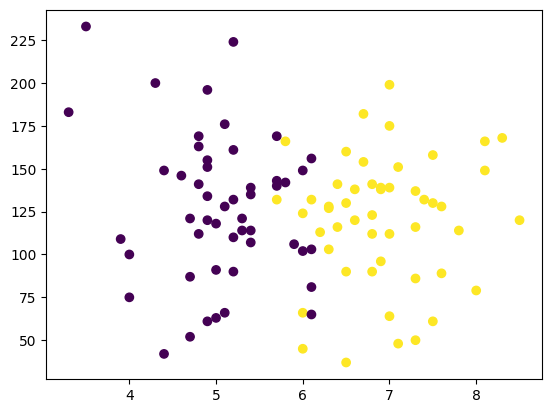

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [ ]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

# iloc is a standard pandas slicing used in dataframe : all rows and 0:2 only r colm 0 and 1 
y = : all rows and -1 last colm 

In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [ ]:
y.shape

(100,)

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)
     

X_train

,cgpa,iq
21,7.1,151.0
60,6.9,139.0
33,6.0,149.0
38,6.5,160.0
63,6.3,128.0
...,...,...
22,4.9,120.0
10,6.0,45.0
16,5.2,224.0
59,4.8,112.0


In [ ]:
y_train

21    1
60    1
33    0
38    1
63    1
     ..
22    0
10    1
16    0
59    0
78    0
Name: placement, Length: 90, dtype: int64

In [ ]:
X_test

,cgpa,iq
28,5.2,90.0
45,6.0,66.0
89,4.9,151.0
66,6.9,96.0
79,6.5,90.0
18,4.0,100.0
57,6.5,130.0
64,7.0,64.0
27,6.0,124.0
29,7.0,112.0


In [ ]:
from sklearn.preprocessing import StandardScaler
     

scaler = StandardScaler()
     

X_train = scaler.fit_transform(X_train)
     

X_train

array([[ 0.96000505,  0.62189057],
       [ 0.78703117,  0.32404498],
       [ 0.00864869,  0.57224964],
       [ 0.4410834 ,  0.84527477],
       [ 0.26810952,  0.05101985],
       [-0.94270766,  0.19994265],
       [-0.85622072, -1.56231046],
       [ 1.39243976, -0.91697834],
       [-1.11568154, -1.83533559],
       [ 2.17082223, -0.14754388],
       [ 0.87351811,  1.81327296],
       [ 0.35459646, -0.24682575],
       [ 1.21946587,  0.15030171],
       [-2.32649872,  1.4161455 ],
       [ 0.52757034, -0.14754388],
       [-0.25081213,  0.42332684],
       [-0.51027295, -0.29646668],
       [-1.0291946 ,  1.06865897],
       [ 1.30595281,  0.79563384],
       [-0.68324684,  0.15030171],
       [-1.37514237,  0.57224964],
       [-0.94270766,  1.73881156],
       [-0.16432519,  0.99419757],
       [-1.72109013, -1.26446487],
       [ 1.30595281,  0.10066078],
       [ 0.00864869, -0.59431228],
       [ 0.52757034,  0.29922451],
       [ 1.39243976,  0.05101985],
       [-0.76973378,

In [ ]:
X_test = scaler.transform(X_test)
     

X_test

array([[-0.68324684, -0.89215787],
       [ 0.00864869, -1.48784906],
       [-0.94270766,  0.62189057],
       [ 0.78703117, -0.74323507],
       [ 0.4410834 , -0.89215787],
       [-1.72109013, -0.64395321],
       [ 0.4410834 ,  0.10066078],
       [ 0.87351811, -1.53749   ],
       [ 0.00864869, -0.04826202],
       [ 0.87351811, -0.34610761]])

In [ ]:
from sklearn.linear_model import LogisticRegression
     

clf = LogisticRegression()
     

# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol